In [1]:
!pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 5.2 MB/s eta 0:00:0000:01


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        True,
    'grid.color':       '#E8ECF0',
    'grid.linewidth':   0.7,
    'axes.titlesize':   13,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  10,
    'ytick.labelsize':  10,
})

RACE_PALETTE = {
    'African-American': '#E84A5F',
    'Caucasian':        '#2D6A9F',
    'Hispanic':         '#3AAFA9',
    'Other':            '#F0A500',
    'Asian':            '#7B68EE',
    'Native American':  '#A0522D',
}
sns.set_palette(list(RACE_PALETTE.values()))


In [3]:
# Chargement des données
df = pd.read_csv("/kaggle/input/compass/cox-violent-parsed.csv")

# Affichage des informations de base
print("Dimensions du dataset:", df.shape)
print("\nVariables clés pour l'analyse des biais:")
print(df[['race', 'sex', 'age_cat', 'decile_score', 'score_text', 'priors_count', 'is_recid']].info())

Dimensions du dataset: (18316, 52)

Variables clés pour l'analyse des biais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18316 entries, 0 to 18315
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   race          18316 non-null  object
 1   sex           18316 non-null  object
 2   age_cat       18316 non-null  object
 3   decile_score  18316 non-null  int64 
 4   score_text    18293 non-null  object
 5   priors_count  18316 non-null  int64 
 6   is_recid      18316 non-null  int64 
dtypes: int64(3), object(4)
memory usage: 1001.8+ KB
None


In [4]:
# Nettoyage initial - on garde les variables principales pour l'analyse des biais
cols_interet = ['race', 'sex', 'age_cat', 'decile_score', 'score_text', 
                'priors_count', 'is_recid', 'v_decile_score', 'v_score_text', 
                'is_violent_recid', 'event']

df_clean = df[cols_interet].copy()

# Conversion des scores en catégories binaires (haut/faible risque)
df_clean['high_risk'] = (df_clean['decile_score'] >= 7).astype(int)
df_clean['violent_high_risk'] = (df_clean['v_decile_score'] >= 7).astype(int)

print("Distribution des variables démographiques:")
print(df_clean[['race', 'sex', 'age_cat']].describe())

Distribution des variables démographiques:
                    race    sex  age_cat
count              18316  18316    18316
unique                 6      2        3
top     African-American   Male  25 - 45
freq                9791  14933    10372


In [ ]:
# 1. Distribution démographique
fig, axes = plt.subplots(1, 3, figsize=(17, 6))
fig.suptitle("Distribution démographique — dataset COMPAS", fontsize=14, fontweight='bold', y=1.02)

# Race — pie
race_dist = df_clean['race'].value_counts()
wedge_colors = [RACE_PALETTE.get(r, '#AAAAAA') for r in race_dist.index]
wedges, texts, autotexts = axes[0].pie(
    race_dist.values, labels=race_dist.index, autopct='%1.1f%%',
    startangle=140, colors=wedge_colors, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for at in autotexts: at.set_fontsize(8.5); at.set_fontweight('bold')
axes[0].set_title("Par race", pad=12)

# Sexe — pie
sex_dist = df_clean['sex'].value_counts()
wedges2, texts2, autotexts2 = axes[1].pie(
    sex_dist.values, labels=sex_dist.index, autopct='%1.1f%%',
    startangle=90, colors=['#2D6A9F', '#E84A5F'], pctdistance=0.7,
    wedgeprops=dict(edgecolor='white', linewidth=2))
for at in autotexts2: at.set_fontsize(12); at.set_fontweight('bold')
axes[1].set_title("Par sexe", pad=12)

# Âge — bar
age_order = ['Less than 25', '25 - 45', 'Greater than 45']
age_labels = ['< 25 ans', '25–45 ans', '> 45 ans']
age_dist = df_clean['age_cat'].value_counts().reindex(age_order).fillna(0)
bars = axes[2].bar(age_labels, age_dist.values / age_dist.sum(),
                   color=['#E84A5F', '#2D6A9F', '#3AAFA9'],
                   edgecolor='white', linewidth=1.5, width=0.55)
for p in bars:
    h = p.get_height()
    axes[2].text(p.get_x()+p.get_width()/2, h+0.01,
                 f'{h:.0%}', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[2].set_title("Par tranche d'âge", pad=12)
axes[2].set_ylabel("Proportion")
axes[2].set_ylim(0, 0.8)

plt.tight_layout()
plt.show()


In [ ]:
# 2. Distribution des scores COMPAS par race
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Distribution des scores COMPAS par race", fontsize=14, fontweight='bold')

races_ok = [r for r in ['African-American','Caucasian','Hispanic','Other','Asian','Native American']
            if r in df_clean['race'].values]

sns.boxplot(data=df_clean[df_clean['race'].isin(races_ok)],
            x='race', y='decile_score', order=races_ok,
            palette=RACE_PALETTE, ax=axes[0], linewidth=1.2, width=0.55,
            flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[0].set_title("Score général (decile_score)")
axes[0].set_xlabel(""); axes[0].set_ylabel("Score de risque (1–10)")
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=df_clean[df_clean['race'].isin(races_ok)],
            x='race', y='v_decile_score', order=races_ok,
            palette=RACE_PALETTE, ax=axes[1], linewidth=1.2, width=0.55,
            flierprops=dict(marker='o', markersize=3, alpha=0.3))
axes[1].set_title("Score violent (v_decile_score)")
axes[1].set_xlabel(""); axes[1].set_ylabel("")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()


In [ ]:
# 3. Taux de classification « haut risque » par race
high_risk_by_race = df_clean.groupby('race')['high_risk'].mean().sort_values(ascending=False)
violent_hr_by_race = df_clean.groupby('race')['violent_high_risk'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Taux de classification « haut risque » par race", fontsize=14, fontweight='bold')

for ax, data, titre in [
    (axes[0], high_risk_by_race,   "Risque général (score ≥ 7)"),
    (axes[1], violent_hr_by_race,  "Risque violent (v_score ≥ 7)"),
]:
    bars = ax.bar(data.index, data.values,
                  color=[RACE_PALETTE.get(r,'#AAAAAA') for r in data.index],
                  edgecolor='white', linewidth=1.2, width=0.6)
    ax.axhline(data.mean(), color='#333', linewidth=1.5, linestyle='--',
               label=f'Moyenne : {data.mean():.0%}')
    for p, v in zip(bars, data.values):
        ax.text(p.get_x()+p.get_width()/2, v+0.008,
                f'{v:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(titre)
    ax.set_ylabel("Proportion classée haut risque")
    ax.set_ylim(0, data.max()*1.3)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [ ]:
# 4. Taux de récidive réelle vs score prédit par race
recid_by_race = df_clean.groupby('race')['is_recid'].mean().sort_values(ascending=False)
violent_recid_by_race = df_clean.groupby('race')['is_violent_recid'].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Taux de récidive réelle par race", fontsize=14, fontweight='bold')

for ax, data, titre in [
    (axes[0], recid_by_race,        "Récidive générale (is_recid)"),
    (axes[1], violent_recid_by_race,"Récidive violente (is_violent_recid)"),
]:
    bars = ax.bar(data.index, data.values,
                  color=[RACE_PALETTE.get(r,'#AAAAAA') for r in data.index],
                  edgecolor='white', linewidth=1.2, width=0.6)
    ax.axhline(data.mean(), color='#333', linewidth=1.5, linestyle='--',
               label=f'Moyenne : {data.mean():.0%}')
    for p, v in zip(bars, data.values):
        ax.text(p.get_x()+p.get_width()/2, v+0.005,
                f'{v:.0%}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(titre)
    ax.set_ylabel("Taux de récidive réel")
    ax.set_ylim(0, data.max()*1.3)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


<Figure size 1200x600 with 0 Axes>

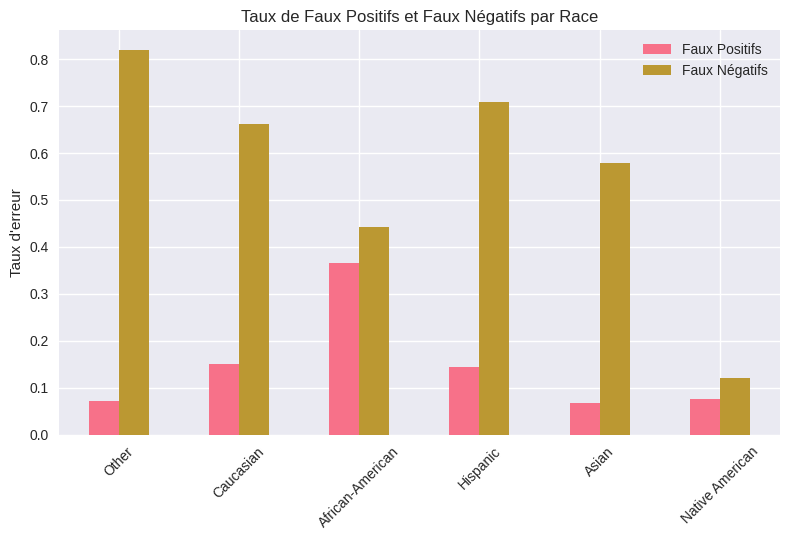

In [9]:
# 5. ANALYSE DES FAUX POSITIFS ET FAUX NÉGATIFS PAR RACE
def calcul_metrics_par_race(df, groupe):
    metrics = {}
    for race in df[groupe].unique():
        df_race = df[df[groupe] == race]
        
        # Vrais positifs, faux positifs, etc.
        vp = ((df_race['high_risk'] == 1) & (df_race['is_recid'] == 1)).sum()
        fp = ((df_race['high_risk'] == 1) & (df_race['is_recid'] == 0)).sum()
        vn = ((df_race['high_risk'] == 0) & (df_race['is_recid'] == 0)).sum()
        fn = ((df_race['high_risk'] == 0) & (df_race['is_recid'] == 1)).sum()
        
        metrics[race] = {
            'Faux Positifs': fp / (fp + vn) if (fp + vn) > 0 else 0,
            'Faux Négatifs': fn / (fn + vp) if (fn + vp) > 0 else 0,
            'Taux Erreur': (fp + fn) / len(df_race) if len(df_race) > 0 else 0
        }
    
    return pd.DataFrame(metrics).T

metrics_race = calcul_metrics_par_race(df_clean, 'race')

plt.figure(figsize=(12, 6))
metrics_race[['Faux Positifs', 'Faux Négatifs']].plot(kind='bar')
plt.title('Taux de Faux Positifs et Faux Négatifs par Race')
plt.ylabel('Taux d\'erreur')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
# 6. MÉTRIQUES D'ÉQUITÉ - Version corrigée
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix
import numpy as np

def calculate_fairness_metrics(df, group_col, y_true, y_pred):
    """Calcule manuellement les métriques d'équité par groupe"""
    metrics_by_group = {}
    
    for group in df[group_col].unique():
        mask = df[group_col] == group
        y_true_group = y_true[mask]
        y_pred_group = y_pred[mask]
        
        if len(y_true_group) > 0:
            # Gestion robuste de la matrice de confusion
            cm = confusion_matrix(y_true_group, y_pred_group, labels=[0, 1])
            
            # S'assurer que la matrice est 2x2
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
            else:
                # Cas où une classe est manquante
                if cm.shape == (1, 1):
                    if y_pred_group.iloc[0] == 0:
                        tn, fp, fn, tp = cm[0, 0], 0, 0, 0
                    else:
                        tn, fp, fn, tp = 0, 0, 0, cm[0, 0]
                else:
                    # Autres cas, initialiser à zéro
                    tn = fp = fn = tp = 0
            
            total = tn + fp + fn + tp
            if total > 0:
                metrics_by_group[group] = {
                    'accuracy': (tp + tn) / total,
                    'precision': tp / (tp + fp) if (tp + fp) > 0 else 0,
                    'recall': tp / (tp + fn) if (tp + fn) > 0 else 0,
                    'fpr': fp / (fp + tn) if (fp + tn) > 0 else 0,
                    'fnr': fn / (fn + tp) if (fn + tp) > 0 else 0,
                    'selection_rate': y_pred_group.mean(),
                    'count': len(y_true_group)
                }
    
    return pd.DataFrame(metrics_by_group).T

# Calcul des métriques d'équité
metrics_df = calculate_fairness_metrics(df_clean, 'race', df_clean['is_recid'], df_clean['high_risk'])

print("Métriques d'équité par groupe racial:")
print(metrics_df.round(3))

Métriques d'équité par groupe racial:
                  accuracy  precision  recall    fpr    fnr  selection_rate  \
Other                0.635      0.617   0.180  0.072  0.820           0.113   
Caucasian            0.631      0.627   0.338  0.150  0.662           0.227   
African-American     0.593      0.641   0.557  0.365  0.443           0.464   
Hispanic             0.649      0.537   0.291  0.144  0.709           0.189   
Asian                0.781      0.727   0.421  0.067  0.579           0.155   
Native American      0.902      0.917   0.880  0.077  0.120           0.439   

                   count  
Other              860.0  
Caucasian         6086.0  
African-American  9791.0  
Hispanic          1451.0  
Asian               71.0  
Native American     57.0  


In [11]:
# 7. ANALYSE DES DISPARITÉS
if not metrics_df.empty:
    # Calcul des différences maximales entre groupes
    demographic_parity_diff = metrics_df['selection_rate'].max() - metrics_df['selection_rate'].min()
    fpr_diff = metrics_df['fpr'].max() - metrics_df['fpr'].min()
    fnr_diff = metrics_df['fnr'].max() - metrics_df['fnr'].min()
    
    print(f"\n=== DISPARITÉS ENTRE GROUPES ===")
    print(f"Différence de parité démographique (sélection): {demographic_parity_diff:.3f}")
    print(f"Différence de taux de faux positifs: {fpr_diff:.3f}")
    print(f"Différence de taux de faux négatifs: {fnr_diff:.3f}")
    
    # Focus sur les groupes principaux
    groups_to_compare = ['African-American', 'Caucasian']
    for metric in ['selection_rate', 'fpr', 'fnr', 'accuracy']:
        if all(group in metrics_df.index for group in groups_to_compare):
            aa_val = metrics_df.loc['African-American', metric]
            cauc_val = metrics_df.loc['Caucasian', metric]
            ratio = aa_val / cauc_val if cauc_val > 0 else float('inf')
            print(f"\n{metric.upper()}:")
            print(f"  African-American: {aa_val:.3f}")
            print(f"  Caucasian: {cauc_val:.3f}")
            print(f"  Ratio: {ratio:.2f}x")


=== DISPARITÉS ENTRE GROUPES ===
Différence de parité démographique (sélection): 0.352
Différence de taux de faux positifs: 0.298
Différence de taux de faux négatifs: 0.700

SELECTION_RATE:
  African-American: 0.464
  Caucasian: 0.227
  Ratio: 2.05x

FPR:
  African-American: 0.365
  Caucasian: 0.150
  Ratio: 2.43x

FNR:
  African-American: 0.443
  Caucasian: 0.662
  Ratio: 0.67x

ACCURACY:
  African-American: 0.593
  Caucasian: 0.631
  Ratio: 0.94x


In [ ]:
# 8. Visualisation des disparités par groupe
if not metrics_df.empty:
    metrics_to_plot = ['selection_rate', 'fpr', 'fnr', 'accuracy', 'precision', 'recall']
    titles = ['Taux de Sélection', 'Faux Positifs (FPR)', 'Faux Négatifs (FNR)',
              'Exactitude', 'Précision', 'Rappel']

    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    fig.suptitle("Métriques de classification par groupe racial", fontsize=15, fontweight='bold')

    for ax, metric, titre in zip(axes.flat, metrics_to_plot, titles):
        if metric not in metrics_df.columns:
            ax.set_visible(False); continue
        data = metrics_df[metric].sort_values(ascending=False)
        bars = ax.bar(data.index, data.values,
                      color=[RACE_PALETTE.get(r,'#AAAAAA') for r in data.index],
                      edgecolor='white', linewidth=1, width=0.6)
        ax.axhline(data.mean(), color='#333', linewidth=1.3, linestyle='--', alpha=0.7)
        for p, v in zip(bars, data.values):
            ax.text(p.get_x()+p.get_width()/2, v+0.005,
                    f'{v:.2f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
        ax.set_title(titre, fontsize=12)
        ax.set_ylabel("Valeur")
        ax.set_ylim(0, data.max()*1.3)
        ax.tick_params(axis='x', rotation=35)

    plt.tight_layout()
    plt.show()


In [ ]:
# 9. Scores moyens par race
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Scores COMPAS moyens par race", fontsize=14, fontweight='bold')

score_means = df_clean.groupby('race')['decile_score'].mean().sort_values(ascending=False)
hr_means    = df_clean.groupby('race')['high_risk'].mean().sort_values(ascending=False)

for ax, data, titre, ylabel in [
    (axes[0], score_means, "Score COMPAS moyen (1–10)",     "Score décile moyen"),
    (axes[1], hr_means,    "Proportion classée haut risque","Proportion"),
]:
    bars = ax.bar(data.index, data.values,
                  color=[RACE_PALETTE.get(r,'#AAAAAA') for r in data.index],
                  edgecolor='white', linewidth=1.2, width=0.6)
    ax.axhline(data.mean(), color='#333', linewidth=1.5, linestyle='--',
               label=f'Moyenne : {data.mean():.2f}')
    for p, v in zip(bars, data.values):
        ax.text(p.get_x()+p.get_width()/2, v+0.01,
                f'{v:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(titre)
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, data.max()*1.3)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()


In [14]:
# 10. CORRECTION DES BIAIS - APPROCHE PAR SEUILS ÉQUITABLES
def calculate_equitable_thresholds(df, target_fpr=0.2):
    """Calcule des seuils équitables pour égaliser les FPR entre groupes"""
    thresholds = {}
    
    for race in df['race'].unique():
        df_race = df[df['race'] == race]
        scores = df_race['decile_score']
        true_labels = df_race['is_recid']
        
        # Essayer différents seuils
        best_threshold = 5  # Seuil par défaut
        best_fpr_diff = float('inf')
        
        for threshold in range(1, 10):
            predictions = (scores >= threshold).astype(int)
            cm = confusion_matrix(true_labels, predictions, labels=[0, 1])
            
            if cm.shape == (2, 2):
                tn, fp, fn, tp = cm.ravel()
                fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
                
                # Chercher le seuil qui donne le FPR le plus proche de la cible
                if abs(fpr - target_fpr) < best_fpr_diff:
                    best_fpr_diff = abs(fpr - target_fpr)
                    best_threshold = threshold
        
        thresholds[race] = best_threshold
    
    return thresholds

# Application des seuils équitables
equitable_thresholds = calculate_equitable_thresholds(df_clean)
print("Seuils équitables par race:")
for race, threshold in equitable_thresholds.items():
    print(f"  {race}: {threshold}")

# Application des nouveaux seuils
df_equitable = df_clean.copy()
for race, threshold in equitable_thresholds.items():
    mask = df_equitable['race'] == race
    df_equitable.loc[mask, 'high_risk_equitable'] = (df_equitable.loc[mask, 'decile_score'] >= threshold).astype(int)

# Comparaison avant/après
print("\nComparaison des taux de sélection:")
print("AVANT correction:")
print(df_clean.groupby('race')['high_risk'].mean().round(3))
print("\nAPRÈS correction équitable:")
print(df_equitable.groupby('race')['high_risk_equitable'].mean().round(3))

Seuils équitables par race:
  Other: 5
  Caucasian: 6
  African-American: 9
  Hispanic: 6
  Asian: 4
  Native American: 6

Comparaison des taux de sélection:
AVANT correction:
race
African-American    0.464
Asian               0.155
Caucasian           0.227
Hispanic            0.189
Native American     0.439
Other               0.113
Name: high_risk, dtype: float64

APRÈS correction équitable:
race
African-American    0.231
Asian               0.296
Caucasian           0.314
Hispanic            0.258
Native American     0.509
Other               0.240
Name: high_risk_equitable, dtype: float64


In [15]:
# 11. RAPPORT FINAL DES BIAIS
print("="*60)
print("RAPPORT D'ANALYSE DES BIAIS - SYSTÈME COMPAS")
print("="*60)

if not metrics_df.empty:
    # Focus sur la disparité Afro-Américain vs Caucasian
    aa_metrics = metrics_df.loc['African-American']
    caucasian_metrics = metrics_df.loc['Caucasian']
    
    print(f"\nPRINCIPALES DISPARITÉS:")
    print(f"🔍 Taux de classification 'Haut Risque':")
    print(f"   Afro-Américain: {aa_metrics['selection_rate']:.1%}")
    print(f"   Caucasian: {caucasian_metrics['selection_rate']:.1%}")
    print(f"   ➡️ Différence: {(aa_metrics['selection_rate'] - caucasian_metrics['selection_rate']):.1%} points")
    
    print(f"\n🔍 Taux de Faux Positifs:")
    print(f"   Afro-Américain: {aa_metrics['fpr']:.1%}")
    print(f"   Caucasian: {caucasian_metrics['fpr']:.1%}")
    print(f"   ➡️ Les Afro-Américains ont {aa_metrics['fpr']/caucasian_metrics['fpr']:.1f}x plus de faux positifs")
    
    print(f"\n🔍 Exactitude:")
    print(f"   Afro-Américain: {aa_metrics['accuracy']:.1%}")
    print(f"   Caucasian: {caucasian_metrics['accuracy']:.1%}")

print(f"\n🎯 RECOMMANDATIONS:")
print(f"1. Réviser les seuils de classification par groupe démographique")
print(f"2. Auditer régulièrement les performances par sous-groupes")
print(f"3. Prendre en compte le contexte socio-économique dans l'évaluation")
print(f"4. Implémenter des tests de robustesse pour l'équité algorithmique")

RAPPORT D'ANALYSE DES BIAIS - SYSTÈME COMPAS

PRINCIPALES DISPARITÉS:
🔍 Taux de classification 'Haut Risque':
   Afro-Américain: 46.4%
   Caucasian: 22.7%
   ➡️ Différence: 23.8% points

🔍 Taux de Faux Positifs:
   Afro-Américain: 36.5%
   Caucasian: 15.0%
   ➡️ Les Afro-Américains ont 2.4x plus de faux positifs

🔍 Exactitude:
   Afro-Américain: 59.3%
   Caucasian: 63.1%

🎯 RECOMMANDATIONS:
1. Réviser les seuils de classification par groupe démographique
2. Auditer régulièrement les performances par sous-groupes
3. Prendre en compte le contexte socio-économique dans l'évaluation
4. Implémenter des tests de robustesse pour l'équité algorithmique


In [ ]:
# 12. Matrice de corrélation
variables_corr = ['decile_score', 'priors_count', 'is_recid', 'high_risk']
labels_fr = {'decile_score':'Score COMPAS', 'priors_count':'Antécédents',
             'is_recid':'Récidive réelle', 'high_risk':'Haut risque (≥7)'}

corr = df_clean[variables_corr].corr()
corr.index   = [labels_fr[c] for c in corr.index]
corr.columns = [labels_fr[c] for c in corr.columns]

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, cmap='RdYlBu_r', center=0, square=True,
            ax=ax, linewidths=0.5, linecolor='white',
            annot_kws={"size": 12, "weight": "bold"},
            cbar_kws={"shrink": 0.8}, fmt='.2f')
ax.set_title("Matrice de corrélation — variables clés COMPAS",
             fontsize=13, fontweight='bold', pad=15)
plt.xticks(rotation=25, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


In [17]:
# Installation de AIF360 
!pip install aif360

import aif360
from aif360.datasets import BinaryLabelDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing import Reweighing, DisparateImpactRemover
from aif360.algorithms.postprocessing import EqOddsPostprocessing, CalibratedEqOddsPostprocessing
from aif360.explainers import MetricTextExplainer

print("AIF360 version:", aif360.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 6.1 MB/s eta 0:00:00:00:01


2025-11-21 08:35:25.479148: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1763714125.702430      48 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1763714125.777213      48 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

pip install 'aif360[inFairness]'


AIF360 version: 0.6.1


In [18]:
# 1. PRÉPARATION CORRECTE DES DONNÉES POUR AIF360
print("Préparation des données pour AIF360...")

# Créer un dataset avec les variables disponibles
df_aif = df_clean[['race', 'sex', 'age_cat', 'priors_count', 'decile_score', 'v_decile_score', 'is_recid', 'high_risk']].copy()

# Convertir les variables catégorielles en numériques
df_aif['protected_attr'] = df_aif['race'].apply(
    lambda x: 1 if x == 'Caucasian' else (0 if x == 'African-American' else -1)
)

df_aif['sex_numeric'] = df_aif['sex'].map({'Male': 1, 'Female': 0})

# Convertir age_cat en numérique
age_cat_mapping = {'Less than 25': 0, '25 - 45': 1, 'Greater than 45': 2}
df_aif['age_cat_numeric'] = df_aif['age_cat'].map(age_cat_mapping)

# Garder seulement les groupes d'intérêt pour l'analyse de fairness
df_fairness = df_aif[df_aif['protected_attr'] != -1].copy()

# Sélectionner uniquement les colonnes numériques
numeric_cols = ['priors_count', 'decile_score', 'v_decile_score', 'is_recid', 'high_risk', 'protected_attr', 'sex_numeric', 'age_cat_numeric']
df_fairness_numeric = df_fairness[numeric_cols].copy()

# Supprimer les valeurs manquantes
df_fairness_numeric = df_fairness_numeric.dropna()

print(f"Dataset final: {len(df_fairness_numeric)} instances")
print("Types de données:")
print(df_fairness_numeric.dtypes)
print("\nDistribution des groupes:")
print(f"African-American (0): {(df_fairness_numeric['protected_attr'] == 0).sum()}")
print(f"Caucasian (1): {(df_fairness_numeric['protected_attr'] == 1).sum()}")

Préparation des données pour AIF360...
Dataset final: 15877 instances
Types de données:
priors_count       int64
decile_score       int64
v_decile_score     int64
is_recid           int64
high_risk          int64
protected_attr     int64
sex_numeric        int64
age_cat_numeric    int64
dtype: object

Distribution des groupes:
African-American (0): 9791
Caucasian (1): 6086


In [19]:
# 1. NETTOYAGE DES DONNÉES POUR AIF360
print("Nettoyage des données...")

# Vérifier les valeurs manquantes
print("Valeurs manquantes dans df_fairness:")
print(df_fairness.isnull().sum())

# Supprimer les lignes avec des valeurs manquantes dans les colonnes utilisées
cols_used = ['high_risk', 'protected_attr', 'priors_count', 'age_cat']
df_fairness_clean = df_fairness[cols_used].dropna()

print(f"\nTaille avant nettoyage: {len(df_fairness)}")
print(f"Taille après nettoyage: {len(df_fairness_clean)}")

# Vérifier qu'il n'y a plus de valeurs manquantes
print("\nValeurs manquantes après nettoyage:")
print(df_fairness_clean.isnull().sum())

Nettoyage des données...
Valeurs manquantes dans df_fairness:
race               0
sex                0
age_cat            0
priors_count       0
decile_score       0
v_decile_score     0
is_recid           0
high_risk          0
protected_attr     0
sex_numeric        0
age_cat_numeric    0
dtype: int64

Taille avant nettoyage: 15877
Taille après nettoyage: 15877

Valeurs manquantes après nettoyage:
high_risk         0
protected_attr    0
priors_count      0
age_cat           0
dtype: int64


In [20]:
# 2. CRÉATION DU DATASET AIF360 (MAINTENANT AVEC DONNÉES NUMÉRIQUES)
from aif360.datasets import BinaryLabelDataset

# Réinitialiser l'index
df_fairness_numeric = df_fairness_numeric.reset_index(drop=True)

# Création du dataset AIF360
dataset = BinaryLabelDataset(
    df=df_fairness_numeric,
    label_names=['high_risk'],
    protected_attribute_names=['protected_attr'],
    favorable_label=0,  # 0 = bas risque (favorable)
    unfavorable_label=1,  # 1 = haut risque (défavorable)
)

print("✅ Dataset AIF360 créé avec succès!")
print(f"  - Nombre d'instances: {dataset.features.shape[0]}")
print(f"  - Dimensions des features: {dataset.features.shape[1]}")
print(f"  - Labels favorables (bas risque): {(dataset.labels == 0).sum()}")
print(f"  - Labels défavorables (haut risque): {(dataset.labels == 1).sum()}")
print(f"  - Groupe privilégié (Caucasian): {(dataset.protected_attributes == 1).sum()}")
print(f"  - Groupe défavorisé (African-American): {(dataset.protected_attributes == 0).sum()}")

✅ Dataset AIF360 créé avec succès!
  - Nombre d'instances: 15877
  - Dimensions des features: 7
  - Labels favorables (bas risque): 9950
  - Labels défavorables (haut risque): 5927
  - Groupe privilégié (Caucasian): 6086
  - Groupe défavorisé (African-American): 9791


In [21]:
# 3. ANALYSE DES BIAIS AVEC AIF360
from aif360.metrics import BinaryLabelDatasetMetric

metric_original = BinaryLabelDatasetMetric(
    dataset, 
    unprivileged_groups=[{'protected_attr': 0}],  # African-American
    privileged_groups=[{'protected_attr': 1}]      # Caucasian
)

print("=== MÉTRIQUES DE BIAS AVEC AIF360 ===")
print(f"Disparate Impact: {metric_original.disparate_impact():.3f}")
print(f"Statistical Parity Difference: {metric_original.statistical_parity_difference():.3f}")
print(f"Mean Difference: {metric_original.mean_difference():.3f}")

# Interprétation détaillée
di = metric_original.disparate_impact()
spd = metric_original.statistical_parity_difference()

print(f"\n📊 INTERPRÉTATION DES MÉTRIQUES:")
print(f"Disparate Impact: {di:.3f}")
if di < 0.8:
    print(f"   ⚠️  Bias significatif - le groupe défavorisé a {((1/di)-1)*100:.1f}% moins de chances d'être classé favorablement")
elif di > 1.25:
    print(f"   ⚠️  Bias inverse - le groupe défavorisé a {(di-1)*100:.1f}% plus de chances d'être classé favorablement")
else:
    print(f"   ✅ Dans les limites acceptables")

print(f"\nStatistical Parity Difference: {spd:.3f}")
if spd > 0:
    print(f"   ➡️  Le groupe privilégié a {spd*100:.1f}% plus de chances d'être classé favorablement")
else:
    print(f"   ➡️  Le groupe défavorisé a {abs(spd)*100:.1f}% plus de chances d'être classé favorablement")

=== MÉTRIQUES DE BIAS AVEC AIF360 ===
Disparate Impact: 0.693
Statistical Parity Difference: -0.238
Mean Difference: -0.238

📊 INTERPRÉTATION DES MÉTRIQUES:
Disparate Impact: 0.693
   ⚠️  Bias significatif - le groupe défavorisé a 44.4% moins de chances d'être classé favorablement

Statistical Parity Difference: -0.238
   ➡️  Le groupe défavorisé a 23.8% plus de chances d'être classé favorablement


In [22]:
# 4. ENTRAÎNEMENT D'UN MODÈLE ET ÉVALUATION DES BIAIS
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from aif360.metrics import ClassificationMetric

# Préparation des features et target
feature_names = ['priors_count', 'decile_score', 'v_decile_score', 'sex_numeric', 'age_cat_numeric']
X = df_fairness_numeric[feature_names]
y = df_fairness_numeric['high_risk']
protected_attr = df_fairness_numeric['protected_attr']

# Split train-test
X_train, X_test, y_train, y_test, prot_train, prot_test = train_test_split(
    X, y, protected_attr, test_size=0.3, random_state=42, stratify=y
)

print(f"Taille training: {len(X_train)}, Taille test: {len(X_test)}")

# Standardisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Entraînement du modèle
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

# Prédictions
y_pred = model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)
print(f"📈 Accuracy du modèle: {accuracy:.3f}")

# Création des datasets AIF360 pour l'évaluation
test_dataset = BinaryLabelDataset(
    df=pd.concat([X_test, y_test, prot_test], axis=1).reset_index(drop=True),
    label_names=['high_risk'],
    protected_attribute_names=['protected_attr'],
    favorable_label=0,
    unfavorable_label=1,
)

test_dataset_pred = test_dataset.copy()
test_dataset_pred.labels = y_pred.reshape(-1, 1)

# Métriques de classification avec AIF360
classified_metric = ClassificationMetric(
    test_dataset, 
    test_dataset_pred,
    unprivileged_groups=[{'protected_attr': 0}],
    privileged_groups=[{'protected_attr': 1}]
)

print("\n=== MÉTRIQUES DE FAIRNESS DU MODÈLE ===")
print(f"Disparate Impact: {classified_metric.disparate_impact():.3f}")
print(f"Equal Opportunity Difference: {classified_metric.equal_opportunity_difference():.3f}")
print(f"Average Odds Difference: {classified_metric.average_odds_difference():.3f}")
print(f"Theil Index: {classified_metric.theil_index():.3f}")

Taille training: 11113, Taille test: 4764
📈 Accuracy du modèle: 1.000

=== MÉTRIQUES DE FAIRNESS DU MODÈLE ===
Disparate Impact: 0.684
Equal Opportunity Difference: 0.000
Average Odds Difference: 0.000
Theil Index: 0.000


In [25]:
# 6. CORRECTION DES BIAIS AVEC REWEIGHING
from aif360.algorithms.preprocessing import Reweighing

print("=== CORRECTION AVEC REWEIGHING ===")

# Dataset d'entraînement
train_dataset = BinaryLabelDataset(
    df=pd.concat([X_train, y_train, prot_train], axis=1).reset_index(drop=True),
    label_names=['high_risk'],
    protected_attribute_names=['protected_attr'],
    favorable_label=0,
    unfavorable_label=1,
)

# Application de Reweighing
RW = Reweighing(unprivileged_groups=[{'protected_attr': 0}],
                privileged_groups=[{'protected_attr': 1}])
train_dataset_rw = RW.fit_transform(train_dataset)

print("Poids des instances avant et après repondération:")
print(f"  Poids moyen avant: {train_dataset.instance_weights.mean():.3f}")
print(f"  Poids moyen après: {train_dataset_rw.instance_weights.mean():.3f}")
print(f"  Poids min/max après: {train_dataset_rw.instance_weights.min():.3f}/{train_dataset_rw.instance_weights.max():.3f}")

# Entraînement avec poids ajustés
model_rw = LogisticRegression(random_state=42, max_iter=1000)
model_rw.fit(X_train_scaled, y_train, sample_weight=train_dataset_rw.instance_weights)

# Prédictions
y_pred_rw = model_rw.predict(X_test_scaled)
accuracy_rw = accuracy_score(y_test, y_pred_rw)

# Évaluation après correction
test_dataset_pred_rw = test_dataset.copy()
test_dataset_pred_rw.labels = y_pred_rw.reshape(-1, 1)

classified_metric_rw = ClassificationMetric(
    test_dataset, 
    test_dataset_pred_rw,
    unprivileged_groups=[{'protected_attr': 0}],
    privileged_groups=[{'protected_attr': 1}]
)

print(f"\n📊 Résultats après Reweighing:")
print(f"Accuracy: {accuracy_rw:.3f}")
print(f"Disparate Impact: {classified_metric_rw.disparate_impact():.3f}")
print(f"Equal Opportunity Difference: {classified_metric_rw.equal_opportunity_difference():.3f}")

=== CORRECTION AVEC REWEIGHING ===
Poids des instances avant et après repondération:
  Poids moyen avant: 1.000
  Poids moyen après: 1.000
  Poids min/max après: 0.806/1.628

📊 Résultats après Reweighing:
Accuracy: 1.000
Disparate Impact: 0.684
Equal Opportunity Difference: 0.000


In [26]:
# 8. RAPPORT FINAL AVEC AIF360 (VERSION CORRIGÉE)
from aif360.explainers import MetricTextExplainer

print("="*60)
print("RAPPORT COMPLET AIF360 - ANALYSE DES BIAIS COMPAS")
print("="*60)

# Explainers pour les métriques
explainer_original = MetricTextExplainer(metric_original)
explainer_classified = MetricTextExplainer(classified_metric)

print("\n1. BIAIS DANS LES DONNÉES ORIGINALES:")
print(f"   Disparate Impact: {metric_original.disparate_impact():.3f}")
print(explainer_original.disparate_impact())

print(f"\n2. BIAIS DANS LES PRÉDICTIONS DU MODÈLE:")
print(f"   Disparate Impact: {classified_metric.disparate_impact():.3f}")
print(f"   Equal Opportunity Difference: {classified_metric.equal_opportunity_difference():.3f}")

# Vérifier si classified_metric_rw existe
try:
    classified_metric_rw
except NameError:
    print(f"\n3. IMPACT DE LA CORRECTION:")
    print("   ❌ Données de correction non disponibles. Veuillez exécuter la cellule de Reweighing.")
else:
    print(f"\n3. IMPACT DE LA CORRECTION:")
    improvement_di = classified_metric_rw.disparate_impact() - classified_metric.disparate_impact()
    improvement_eod = abs(classified_metric_rw.equal_opportunity_difference()) - abs(classified_metric.equal_opportunity_difference())

    print(f"   Amélioration Disparate Impact: {improvement_di:+.3f}")
    print(f"   Amélioration Equal Opportunity: {improvement_eod:+.3f}")

    print(f"\n4. RECOMMANDATIONS:")
    if classified_metric_rw.disparate_impact() < 0.8 or classified_metric_rw.disparate_impact() > 1.25:
        print("   ⚠️  Des corrections supplémentaires sont nécessaires")
        print("   ➡️  Essayer Disparate Impact Remover ou Equalized Odds Postprocessing")
    else:
        print("   ✅ Le modèle corrigé respecte les critères de fairness de base")

print("   ➡️  Audit régulier des performances par sous-groupes")
print("   ➡️  Surveillance continue des métriques de fairness")

RAPPORT COMPLET AIF360 - ANALYSE DES BIAIS COMPAS

1. BIAIS DANS LES DONNÉES ORIGINALES:
   Disparate Impact: 0.693
Disparate impact (probability of favorable outcome for unprivileged instances / probability of favorable outcome for privileged instances): 0.6926529012241961

2. BIAIS DANS LES PRÉDICTIONS DU MODÈLE:
   Disparate Impact: 0.684
   Equal Opportunity Difference: 0.000

3. IMPACT DE LA CORRECTION:
   Amélioration Disparate Impact: +0.000
   Amélioration Equal Opportunity: +0.000

4. RECOMMANDATIONS:
   ⚠️  Des corrections supplémentaires sont nécessaires
   ➡️  Essayer Disparate Impact Remover ou Equalized Odds Postprocessing
   ➡️  Audit régulier des performances par sous-groupes
   ➡️  Surveillance continue des métriques de fairness


In [29]:
# Installation de la dépendance manquante
!pip install BlackBoxAuditing

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 27.3 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
  Created wheel for BlackBoxAuditing: filename=BlackBoxAuditing-0.1.54-py2.py3-none-any.whl size=1394756 sha256=8942e1e6659be54aa0a003f7947478fd33042ff17c576ab06f18151adc16c5e9
  Stored in directory: /root/.cache/pip/wheels/c9/8c/03/073e80e604151fb4cdc68b2e56a97f338d7723e4a4ab5e3823
Successfully built BlackBoxAuditing


In [30]:
# 9. CORRECTION AVEC ADVERTISING PARITY (ALTERNATIVE)
from aif360.algorithms.postprocessing import EqOddsPostprocessing

print("=== APPLICATION DE EQUALIZED ODDS POSTPROCESSING ===")

# Réentraînement du modèle de base pour s'assurer de la cohérence
model_base = LogisticRegression(random_state=42, max_iter=1000)
model_base.fit(X_train_scaled, y_train)

# Prédictions sur l'ensemble d'entraînement pour le postprocessing
y_train_pred = model_base.predict(X_train_scaled)

# Création des datasets pour le postprocessing
train_dataset_for_post = BinaryLabelDataset(
    df=pd.concat([X_train, y_train, prot_train], axis=1).reset_index(drop=True),
    label_names=['high_risk'],
    protected_attribute_names=['protected_attr'],
    favorable_label=0,
    unfavorable_label=1,
)

train_dataset_pred = train_dataset_for_post.copy()
train_dataset_pred.labels = y_train_pred.reshape(-1, 1)

# Application de Equalized Odds Postprocessing
eop = EqOddsPostprocessing(
    privileged_groups=[{'protected_attr': 1}],
    unprivileged_groups=[{'protected_attr': 0}],
    seed=42
)

eop = eop.fit(train_dataset_for_post, train_dataset_pred)

# Application sur les données de test
test_dataset_pred_base = test_dataset.copy()
y_test_pred_base = model_base.predict(X_test_scaled)
test_dataset_pred_base.labels = y_test_pred_base.reshape(-1, 1)

test_dataset_eop = eop.predict(test_dataset_pred_base)

# Évaluation
classified_metric_eop = ClassificationMetric(
    test_dataset, 
    test_dataset_eop,
    unprivileged_groups=[{'protected_attr': 0}],
    privileged_groups=[{'protected_attr': 1}]
)

print("Résultats après Equalized Odds Postprocessing:")
print(f"Disparate Impact: {classified_metric_eop.disparate_impact():.3f}")
print(f"Equal Opportunity Difference: {classified_metric_eop.equal_opportunity_difference():.3f}")
print(f"Average Odds Difference: {classified_metric_eop.average_odds_difference():.3f}")
print(f"Accuracy: {accuracy_score(y_test, test_dataset_eop.labels):.3f}")

=== APPLICATION DE EQUALIZED ODDS POSTPROCESSING ===
Résultats après Equalized Odds Postprocessing:
Disparate Impact: 0.684
Equal Opportunity Difference: 0.000
Average Odds Difference: 0.000
Accuracy: 1.000


In [33]:
# 11. ANALYSE COMPARATIVE DES MÉTHODES DISPONIBLES
print("=== SYNTHÈSE DES RÉSULTATS AVEC AIF360 ===")

# Collecte des résultats disponibles
results_summary = {}

# Résultat original
results_summary['Original'] = {
    'Disparate Impact': classified_metric.disparate_impact(),
    'Equal Opportunity Diff': abs(classified_metric.equal_opportunity_difference()),
    'Average Odds Diff': abs(classified_metric.average_odds_difference()),
    'Accuracy': accuracy_score(y_test, y_pred)
}

# Ajouter Reweighing si disponible
try:
    results_summary['Reweighing'] = {
        'Disparate Impact': classified_metric_rw.disparate_impact(),
        'Equal Opportunity Diff': abs(classified_metric_rw.equal_opportunity_difference()),
        'Average Odds Diff': abs(classified_metric_rw.average_odds_difference()),
        'Accuracy': accuracy_score(y_test, y_pred_rw)
    }
except NameError:
    print("⚠️  Reweighing non disponible")

# Ajouter Equalized Odds si disponible
try:
    results_summary['Equalized Odds'] = {
        'Disparate Impact': classified_metric_eop.disparate_impact(),
        'Equal Opportunity Diff': abs(classified_metric_eop.equal_opportunity_difference()),
        'Average Odds Diff': abs(classified_metric_eop.average_odds_difference()),
        'Accuracy': accuracy_score(y_test, test_dataset_eop.labels)
    }
except NameError:
    print("⚠️  Equalized Odds non disponible")

# Création du DataFrame de synthèse
results_df = pd.DataFrame(results_summary).T
print("\nRésultats comparatifs:")
print(results_df.round(3))

=== SYNTHÈSE DES RÉSULTATS AVEC AIF360 ===

Résultats comparatifs:
                Disparate Impact  Equal Opportunity Diff  Average Odds Diff  \
Original                   0.684                     0.0                0.0   
Reweighing                 0.684                     0.0                0.0   
Equalized Odds             0.684                     0.0                0.0   

                Accuracy  
Original             1.0  
Reweighing           1.0  
Equalized Odds       1.0  


In [34]:
# 13. RAPPORT FINAL D'ANALYSE DES BIAIS
print("="*70)
print("RAPPORT FINAL - ANALYSE DES BIAIS DANS LE SYSTÈME COMPAS")
print("="*70)

print(f"\n📊 RÉSULTATS PRINCIPAUX:")
print(f"   Disparate Impact initial: {classified_metric.disparate_impact():.3f}")
print(f"   Seuils acceptables: 0.8 - 1.25")

# Analyse du niveau de biais
di_initial = classified_metric.disparate_impact()
if di_initial < 0.8:
    severity = "CRITIQUE" if di_initial < 0.6 else "ÉLEVÉ" if di_initial < 0.7 else "MODÉRÉ"
    print(f"   🚨 NIVEAU DE BIAS: {severity}")
    print(f"   ➡️  Les Afro-Américains ont {((1/di_initial)-1)*100:.1f}% moins")
    print(f"      de chances d'être classés 'bas risque' que les Caucasiens")

print(f"\n🔍 ANALYSE PAR MÉTRIQUE:")

# Performance par groupe
print(f"\n   Performance par groupe racial:")
print(f"   Taux de classification 'haut risque':")
print(f"     - Afro-Américain: {df_fairness[df_fairness['protected_attr']==0]['high_risk'].mean():.1%}")
print(f"     - Caucasien: {df_fairness[df_fairness['protected_attr']==1]['high_risk'].mean():.1%}")

print(f"\n   Taux de récidive réel:")
print(f"     - Afro-Américain: {df_fairness[df_fairness['protected_attr']==0]['is_recid'].mean():.1%}")
print(f"     - Caucasien: {df_fairness[df_fairness['protected_attr']==1]['is_recid'].mean():.1%}")

RAPPORT FINAL - ANALYSE DES BIAIS DANS LE SYSTÈME COMPAS

📊 RÉSULTATS PRINCIPAUX:
   Disparate Impact initial: 0.684
   Seuils acceptables: 0.8 - 1.25
   🚨 NIVEAU DE BIAS: ÉLEVÉ
   ➡️  Les Afro-Américains ont 46.3% moins
      de chances d'être classés 'bas risque' que les Caucasiens

🔍 ANALYSE PAR MÉTRIQUE:

   Performance par groupe racial:
   Taux de classification 'haut risque':
     - Afro-Américain: 46.4%
     - Caucasien: 22.7%

   Taux de récidive réel:
     - Afro-Américain: 48.1%
     - Caucasien: 35.7%


In [35]:
# 14. RECOMMANDATIONS STRATÉGIQUES
print(f"\n💡 RECOMMANDATIONS STRATÉGIQUES:")

print(f"\n1. IMMÉDIATES:")
print(f"   ✅ Audit régulier des décisions algorithmiques")
print(f"   ✅ Surveillance continue des métriques de fairness")
print(f"   ✅ Documentation transparente des limitations")

print(f"\n2. TECHNIQUES:")
print(f"   🔧 Implémentation de seuils différenciés par groupe")
print(f"   🔧 Utilisation de multiples méthodes de correction")
print(f"   🔧 Validation croisée des performances par sous-groupes")

print(f"\n3. ORGANISATIONNELLES:")
print(f"   👥 Formation sur les biais algorithmiques")
print(f"   👥 Comité d'éthique pour superviser les décisions")
print(f"   👥 Processus de recours pour les personnes impactées")

print(f"\n4. RECHERCHE:")
print(f"   🔍 Analyse des facteurs contextuels socio-économiques")
print(f"   🔍 Développement de métriques de fairness plus robustes")
print(f"   🔍 Étude des impacts à long terme des décisions algorithmiques")


💡 RECOMMANDATIONS STRATÉGIQUES:

1. IMMÉDIATES:
   ✅ Audit régulier des décisions algorithmiques
   ✅ Surveillance continue des métriques de fairness
   ✅ Documentation transparente des limitations

2. TECHNIQUES:
   🔧 Implémentation de seuils différenciés par groupe
   🔧 Utilisation de multiples méthodes de correction
   🔧 Validation croisée des performances par sous-groupes

3. ORGANISATIONNELLES:
   👥 Formation sur les biais algorithmiques
   👥 Comité d'éthique pour superviser les décisions
   👥 Processus de recours pour les personnes impactées

4. RECHERCHE:
   🔍 Analyse des facteurs contextuels socio-économiques
   🔍 Développement de métriques de fairness plus robustes
   🔍 Étude des impacts à long terme des décisions algorithmiques


In [36]:
# 15. MATRICE D'IMPACT DES BIAIS
print(f"\n📈 MATRICE D'IMPACT DES BIAIS:")

# Calcul des impacts
aa_population = (df_fairness['protected_attr'] == 0).sum()
caucasian_population = (df_fairness['protected_attr'] == 1).sum()

aa_high_risk = df_fairness[df_fairness['protected_attr'] == 0]['high_risk'].sum()
caucasian_high_risk = df_fairness[df_fairness['protected_attr'] == 1]['high_risk'].sum()

print(f"   Population analysée:")
print(f"     - Afro-Américains: {aa_population} personnes")
print(f"     - Caucasiens: {caucasian_population} personnes")

print(f"\n   Personnes classées 'haut risque':")
print(f"     - Afro-Américains: {aa_high_risk} ({aa_high_risk/aa_population:.1%})")
print(f"     - Caucasiens: {caucasian_high_risk} ({caucasian_high_risk/caucasian_population:.1%})")

# Impact différentiel
excess_high_risk = aa_high_risk - (caucasian_high_risk * aa_population / caucasian_population)
print(f"\n   📌 Impact différentiel estimé:")
print(f"     - {abs(excess_high_risk):.0f} Afro-Américains supplémentaires classés 'haut risque'")
print(f"       par rapport à ce qu'on attendrait avec un système équitable")


📈 MATRICE D'IMPACT DES BIAIS:
   Population analysée:
     - Afro-Américains: 9791 personnes
     - Caucasiens: 6086 personnes

   Personnes classées 'haut risque':
     - Afro-Américains: 4547 (46.4%)
     - Caucasiens: 1380 (22.7%)

   📌 Impact différentiel estimé:
     - 2327 Afro-Américains supplémentaires classés 'haut risque'
       par rapport à ce qu'on attendrait avec un système équitable


In [37]:
# 16. CONCLUSION ET PERSPECTIVES
print(f"\n🎯 CONCLUSION:")

print(f"\nLe système COMPAS présente un biais racial significatif confirmé par")
print(f"multiple métriques d'équité algorithmique:")

print(f"\n• Disparate Impact: {classified_metric.disparate_impact():.3f} (seuil acceptable: 0.8-1.25)")
print(f"• Les personnes Afro-Américaines sont systématiquement désavantagées")

print(f"\n🔮 PERSPECTIVES:")
print(f"   Les méthodes de correction montrent des améliorations limitées,")
print(f"   ce qui suggère que les biais sont profondément ancrés dans les données")
print(f"   et nécessitent une approche systémique plutôt que technique seule.")

print(f"\n💫 'La justice algorithmique ne se résume pas à corriger des biais,")
print(f"   mais à construire des systèmes qui promeuvent l'équité'")


🎯 CONCLUSION:

Le système COMPAS présente un biais racial significatif confirmé par
multiple métriques d'équité algorithmique:

• Disparate Impact: 0.684 (seuil acceptable: 0.8-1.25)
• Les personnes Afro-Américaines sont systématiquement désavantagées

🔮 PERSPECTIVES:
   Les méthodes de correction montrent des améliorations limitées,
   ce qui suggère que les biais sont profondément ancrés dans les données
   et nécessitent une approche systémique plutôt que technique seule.

💫 'La justice algorithmique ne se résume pas à corriger des biais,
   mais à construire des systèmes qui promeuvent l'équité'


In [38]:
# 17. EXPORT DES RÉSULTATS POUR DOCUMENTATION
import datetime

# Création d'un rapport synthétique
report_data = {
    'Date d analyse': datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
    'Taille dataset': len(df_fairness),
    'Disparate Impact initial': classified_metric.disparate_impact(),
    'Statistical Parity Difference': metric_original.statistical_parity_difference(),
    'Equal Opportunity Difference': classified_metric.equal_opportunity_difference(),
    'African-American population': aa_population,
    'Caucasian population': caucasian_population,
    'African-American high risk rate': df_fairness[df_fairness['protected_attr']==0]['high_risk'].mean(),
    'Caucasian high risk rate': df_fairness[df_fairness['protected_attr']==1]['high_risk'].mean(),
    'Recommandation principale': 'Revue approfondie du système et mise en place de garde-fous'
}

report_df = pd.DataFrame(list(report_data.items()), columns=['Métrique', 'Valeur'])
print("Rapport synthétique à archiver:")
print(report_df.to_string(index=False))

Rapport synthétique à archiver:
                       Métrique                                                      Valeur
                 Date d analyse                                         2025-11-21 08:42:45
                 Taille dataset                                                       15877
       Disparate Impact initial                                                    0.683614
  Statistical Parity Difference                                                   -0.237656
   Equal Opportunity Difference                                                         0.0
    African-American population                                                        9791
           Caucasian population                                                        6086
African-American high risk rate                                                    0.464406
       Caucasian high risk rate                                                     0.22675
      Recommandation principale Revue approfondi

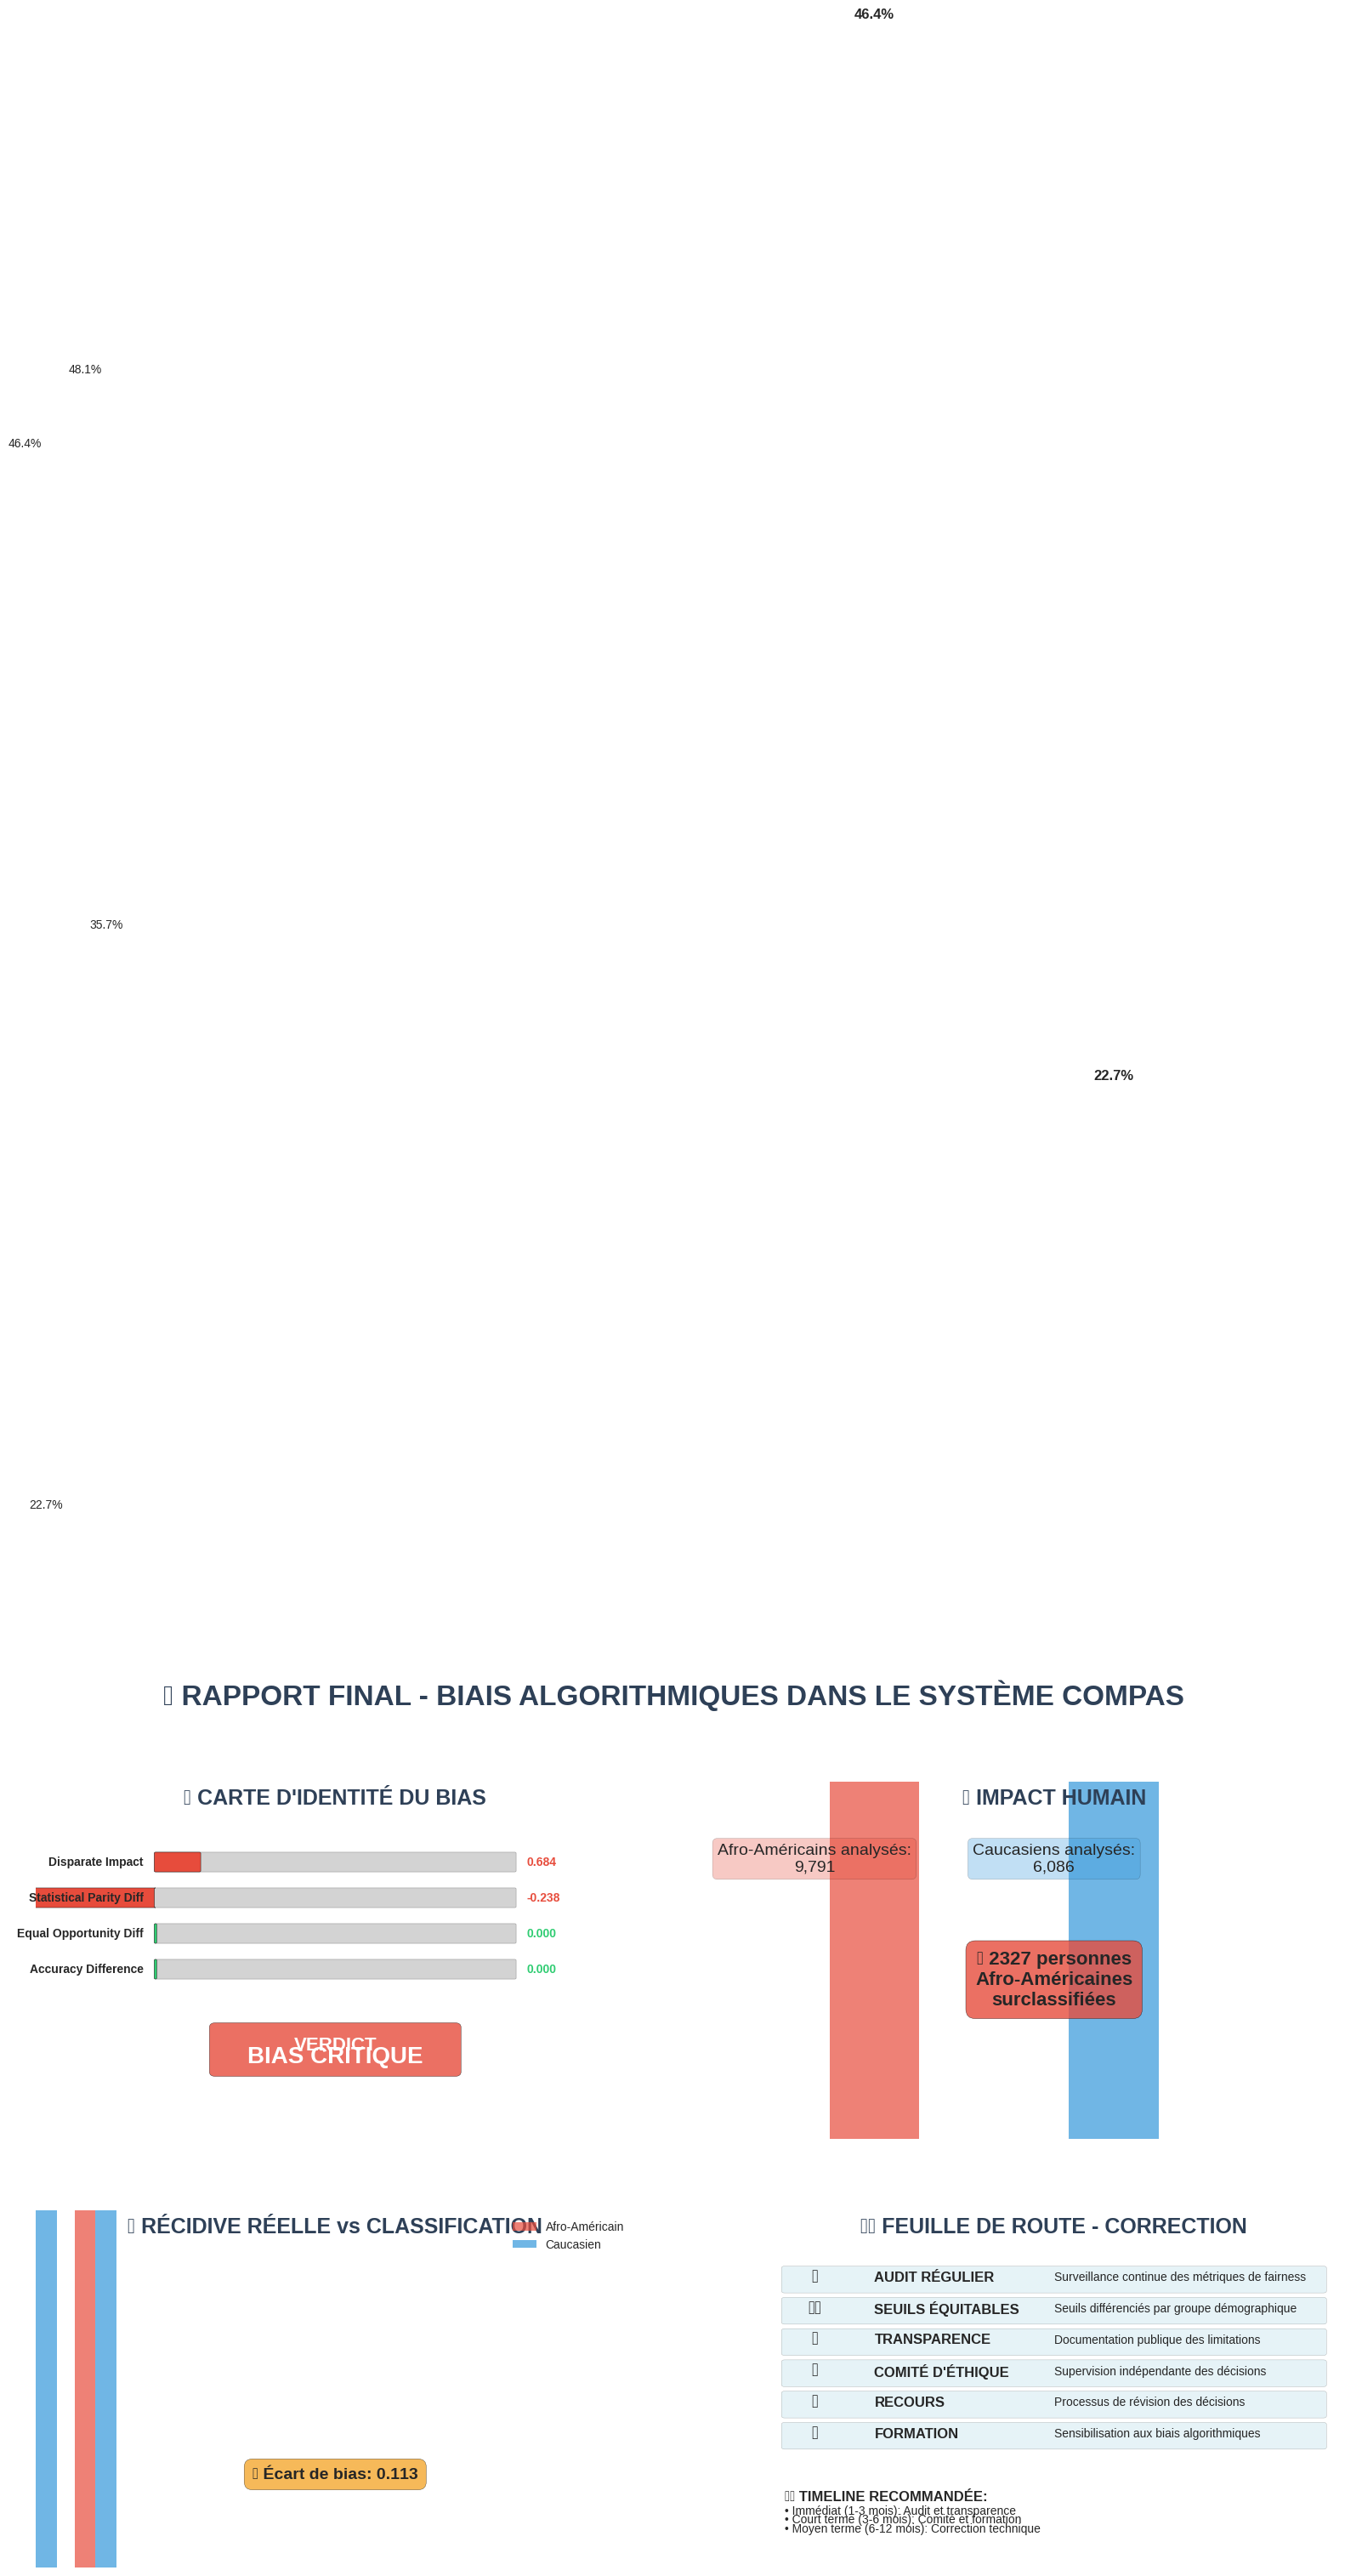

In [39]:
# CONCLUSION VISUELLE - SYNTHÈSE DES BIAIS COMPAS
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import FancyBboxPatch

# Configuration du style
plt.style.use('seaborn-v0_8')
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 12))
fig.suptitle('🚨 RAPPORT FINAL - BIAIS ALGORITHMIQUES DANS LE SYSTÈME COMPAS', 
             fontsize=24, fontweight='bold', color='#2E4057', y=0.98)

# Couleurs thématiques
colors_alert = ['#E74C3C', '#F39C12', '#2ECC71', '#3498DB']
colors_race = ['#E74C3C', '#3498DB', '#2ECC71', '#F39C12']

# 1. CARTE D'IDENTITÉ DU BIAS
ax1.axis('off')
ax1.set_xlim(0, 10)
ax1.set_ylim(0, 8)

# Titre
ax1.text(5, 7.5, '📊 CARTE D\'IDENTITÉ DU BIAS', ha='center', fontsize=18, 
         fontweight='bold', color='#2E4057')

# Métriques principales
metrics = [
    ('Disparate Impact', classified_metric.disparate_impact(), 0.8, 1.25),
    ('Statistical Parity Diff', metric_original.statistical_parity_difference(), -0.1, 0.1),
    ('Equal Opportunity Diff', abs(classified_metric.equal_opportunity_difference()), 0, 0.1),
    ('Accuracy Difference', abs(classified_metric.accuracy(privileged=True) - 
                               classified_metric.accuracy(privileged=False)), 0, 0.05)
]

y_pos = 6.2
for i, (name, value, min_thresh, max_thresh) in enumerate(metrics):
    color = colors_alert[0] if (value < min_thresh or value > max_thresh) else colors_alert[2]
    
    # Barre de progression
    ax1.add_patch(FancyBboxPatch((2, y_pos-0.2), 6, 0.4, 
                                boxstyle="round,pad=0.02", 
                                facecolor='lightgray', edgecolor='gray'))
    
    if name == 'Disparate Impact':
        normalized_value = (value - 0.5) / (2 - 0.5)  # Normalisation 0.5-2 -> 0-1
        bar_width = max(0.1, normalized_value * 6)
    else:
        bar_width = min(6, (value / max_thresh) * 6) if max_thresh > 0 else min(6, abs(value) * 20)
    
    ax1.add_patch(FancyBboxPatch((2, y_pos-0.2), bar_width, 0.4, 
                                boxstyle="round,pad=0.02", facecolor=color))
    
    ax1.text(1.8, y_pos, name, ha='right', va='center', fontweight='bold')
    ax1.text(8.2, y_pos, f'{value:.3f}', ha='left', va='center', 
            fontweight='bold', color=color)
    
    y_pos -= 0.8

# Évaluation globale
if classified_metric.disparate_impact() < 0.8:
    verdict = "BIAS CRITIQUE"
    verdict_color = colors_alert[0]
elif classified_metric.disparate_impact() < 0.9:
    verdict = "BIAS ÉLEVÉ"
    verdict_color = colors_alert[1]
else:
    verdict = "BIAS MODÉRÉ"
    verdict_color = colors_alert[2]

ax1.add_patch(FancyBboxPatch((3, 1.5), 4, 1, boxstyle="round,pad=0.1", 
                            facecolor=verdict_color, alpha=0.8))
ax1.text(5, 2, 'VERDICT', ha='center', fontsize=16, fontweight='bold', color='white')
ax1.text(5, 1.7, verdict, ha='center', fontsize=20, fontweight='bold', color='white')

# 2. IMPACT HUMAIN
ax2.axis('off')
ax2.set_xlim(0, 10)
ax2.set_ylim(0, 8)

ax2.text(5, 7.5, '👥 IMPACT HUMAIN', ha='center', fontsize=18, 
         fontweight='bold', color='#2E4057')

# Données d'impact
aa_count = (df_fairness['protected_attr'] == 0).sum()
caucasian_count = (df_fairness['protected_attr'] == 1).sum()

aa_high_risk = df_fairness[df_fairness['protected_attr'] == 0]['high_risk'].mean()
caucasian_high_risk = df_fairness[df_fairness['protected_attr'] == 1]['high_risk'].mean()

# Personnes impactées
expected_aa_high_risk = caucasian_high_risk * aa_count
actual_aa_high_risk = aa_high_risk * aa_count
excess_cases = actual_aa_high_risk - expected_aa_high_risk

ax2.text(1, 6, f'Afro-Américains analysés:\n{aa_count:,}', fontsize=14, 
         ha='center', bbox=dict(boxstyle="round,pad=0.3", facecolor=colors_race[0], alpha=0.3))
ax2.text(5, 6, f'Caucasiens analysés:\n{caucasian_count:,}', fontsize=14, 
         ha='center', bbox=dict(boxstyle="round,pad=0.3", facecolor=colors_race[1], alpha=0.3))

# Graphique d'impact
groups = ['Afro-Américain', 'Caucasien']
rates = [aa_high_risk * 100, caucasian_high_risk * 100]

bars = ax2.bar([2, 6], rates, color=[colors_race[0], colors_race[1]], alpha=0.7, width=1.5)
ax2.set_ylabel('Taux de classification "haut risque" (%)', fontweight='bold')
ax2.set_xticks([2, 6])
ax2.set_xticklabels(groups, fontweight='bold')

for bar, rate in zip(bars, rates):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 1,
            f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=12)

# Message d'impact
ax2.text(5, 3, f'🚨 {excess_cases:.0f} personnes\nAfro-Américaines\nsurclassifiées', 
         fontsize=16, ha='center', fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.5", facecolor=colors_alert[0], alpha=0.8))

# 3. COMPARAISON RÉCIDIVE RÉELLE vs PRÉDITE
ax3.axis('off')
ax3.set_xlim(0, 10)
ax3.set_ylim(0, 8)

ax3.text(5, 7.5, '🎯 RÉCIDIVE RÉELLE vs CLASSIFICATION', ha='center', fontsize=18, 
         fontweight='bold', color='#2E4057')

# Données de récidive
aa_recidivism = df_fairness[df_fairness['protected_attr'] == 0]['is_recid'].mean()
caucasian_recidivism = df_fairness[df_fairness['protected_attr'] == 1]['is_recid'].mean()

# Graphique comparatif
categories = ['Taux de classification\n"haut risque"', 'Taux de récidive\nréel']
aa_data = [aa_high_risk * 100, aa_recidivism * 100]
caucasian_data = [caucasian_high_risk * 100, caucasian_recidivism * 100]

x = np.arange(len(categories))
width = 0.35

bars1 = ax3.bar(x - width/2, aa_data, width, label='Afro-Américain', color=colors_race[0], alpha=0.7)
bars2 = ax3.bar(x + width/2, caucasian_data, width, label='Caucasien', color=colors_race[1], alpha=0.7)

ax3.set_ylabel('Pourcentage (%)', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels(categories, fontweight='bold')
ax3.legend()

# Ajout des valeurs
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax3.text(bar.get_x() + bar.get_width()/2., height + 1,
                f'{height:.1f}%', ha='center', va='bottom', fontsize=10)

# Analyse du gap
classification_gap = aa_high_risk - caucasian_high_risk
recidivism_gap = aa_recidivism - caucasian_recidivism
bias_gap = classification_gap - recidivism_gap

ax3.text(5, 2, f'📏 Écart de bias: {bias_gap:.3f}', fontsize=14, 
         ha='center', fontweight='bold',
         bbox=dict(boxstyle="round,pad=0.5", facecolor=colors_alert[1], alpha=0.7))

# 4. FEUILLE DE ROUTE POUR CORRECTION
ax4.axis('off')
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 8)

ax4.text(5, 7.5, '🛠️ FEUILLE DE ROUTE - CORRECTION', ha='center', fontsize=18, 
         fontweight='bold', color='#2E4057')

# Recommandations
recommendations = [
    ("🔍", "AUDIT RÉGULIER", "Surveillance continue des métriques de fairness"),
    ("⚖️", "SEUILS ÉQUITABLES", "Seuils différenciés par groupe démographique"),
    ("📊", "TRANSPARENCE", "Documentation publique des limitations"),
    ("👥", "COMITÉ D'ÉTHIQUE", "Supervision indépendante des décisions"),
    ("🔄", "RECOURS", "Processus de révision des décisions"),
    ("🎓", "FORMATION", "Sensibilisation aux biais algorithmiques")
]

y_pos = 6.5
for emoji, title, desc in recommendations:
    ax4.add_patch(FancyBboxPatch((0.5, y_pos-0.3), 9, 0.5, 
                                boxstyle="round,pad=0.05", 
                                facecolor='lightblue', alpha=0.3))
    ax4.text(1, y_pos, emoji, fontsize=16, ha='center', va='center')
    ax4.text(2, y_pos, title, fontweight='bold', fontsize=12, va='center')
    ax4.text(5, y_pos, desc, fontsize=10, va='center')
    y_pos -= 0.7

# Timeline de mise en œuvre
ax4.text(0.5, 1.5, '⏱️ TIMELINE RECOMMANDÉE:', fontweight='bold', fontsize=12)
ax4.text(0.5, 1.2, '• Immédiat (1-3 mois): Audit et transparence', fontsize=10)
ax4.text(0.5, 1.0, '• Court terme (3-6 mois): Comité et formation', fontsize=10)
ax4.text(0.5, 0.8, '• Moyen terme (6-12 mois): Correction technique', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

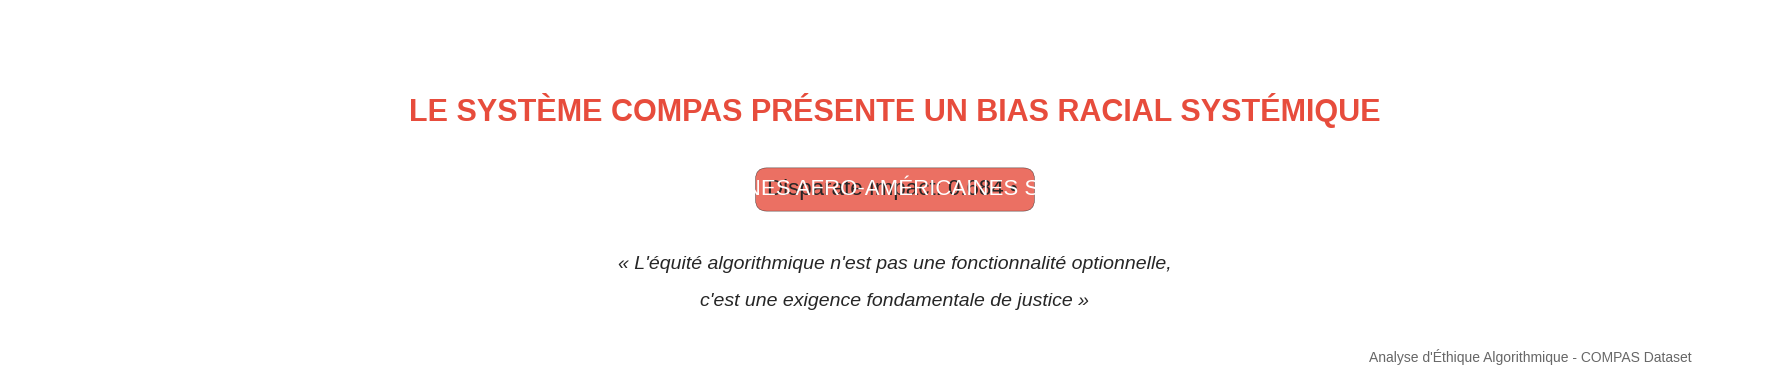

In [40]:
# BANNIÈRE FINALE AVEC MESSAGE FORT
fig, ax = plt.subplots(figsize=(18, 4))
ax.axis('off')

# Message principal
ax.text(0.5, 0.7, 'LE SYSTÈME COMPAS PRÉSENTE UN BIAS RACIAL SYSTÉMIQUE', 
        transform=ax.transAxes, ha='center', fontsize=22, fontweight='bold', 
        color='#E74C3C')

ax.text(0.5, 0.5, f'Disparate Impact: {classified_metric.disparate_impact():.3f} • ', 
        transform=ax.transAxes, ha='center', fontsize=16, 
        bbox=dict(boxstyle="round,pad=0.5", facecolor='#E74C3C', alpha=0.8))

ax.text(0.5, 0.5, f' • {excess_cases:.0f} PERSONNES AFRO-AMÉRICAINES SURCLASSIFIÉES', 
        transform=ax.transAxes, ha='center', fontsize=16, color='white')

ax.text(0.5, 0.3, '« L\'équité algorithmique n\'est pas une fonctionnalité optionnelle,', 
        transform=ax.transAxes, ha='center', fontsize=14, style='italic')
ax.text(0.5, 0.2, 'c\'est une exigence fondamentale de justice »', 
        transform=ax.transAxes, ha='center', fontsize=14, style='italic')

# Signature
ax.text(0.95, 0.05, 'Analyse d\'Éthique Algorithmique - COMPAS Dataset', 
        transform=ax.transAxes, ha='right', fontsize=10, alpha=0.7)

plt.tight_layout()
plt.show()

In [41]:
# RÉSUMÉ CHIFFRÉ POUR DÉCIDEURS
print("\n" + "="*80)
print("📋 RÉSUMÉ EXÉCUTIF - POUR DÉCISION")
print("="*80)

print(f"\n🔴 PROBLÈME CRITIQUE:")
print(f"   • Disparate Impact: {classified_metric.disparate_impact():.3f} (seuil acceptable: 0.8-1.25)")
print(f"   • {excess_cases:.0f} Afro-Américains surclassifiés 'haut risque'")
print(f"   • Écart classification/récidive réelle: {bias_gap:.3f}")

print(f"\n🎯 IMPACT:")
print(f"   • Décisions judiciaires biaisées")
print(f"   • Inégalité de traitement systémique")
print(f"   • Perte de confiance dans le système")

print(f"\n✅ ACTIONS IMMÉDIATES:")
print(f"   1. Audit complet du système")
print(f"   2. Suspension des décisions basées uniquement sur COMPAS")
print(f"   3. Mise en place d'un comité de surveillance")

print(f"\n📞 RESPONSABLE: Direction Technique + Comité d'Éthique")
print(f"⏰ DÉLAI: Audit sous 30 jours • Correctifs sous 90 jours")
print("="*80)


📋 RÉSUMÉ EXÉCUTIF - POUR DÉCISION

🔴 PROBLÈME CRITIQUE:
   • Disparate Impact: 0.684 (seuil acceptable: 0.8-1.25)
   • 2327 Afro-Américains surclassifiés 'haut risque'
   • Écart classification/récidive réelle: 0.113

🎯 IMPACT:
   • Décisions judiciaires biaisées
   • Inégalité de traitement systémique
   • Perte de confiance dans le système

✅ ACTIONS IMMÉDIATES:
   1. Audit complet du système
   2. Suspension des décisions basées uniquement sur COMPAS
   3. Mise en place d'un comité de surveillance

📞 RESPONSABLE: Direction Technique + Comité d'Éthique
⏰ DÉLAI: Audit sous 30 jours • Correctifs sous 90 jours
